In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [6]:
np.random.seed(23)

mu_vec1 = np.array([0,0,0])
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample = np.random.multivariate_normal(mu_vec1 , cov_mat1 , 20)

df = pd.DataFrame(class1_sample , columns = ['features1' , 'features2', 'features3'])
df['target'] = 1

mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample = np.random.multivariate_normal(mu_vec2 , cov_mat2 , 20)

df1 = pd.DataFrame(class2_sample , columns = ['features1' , 'features2' , 'features3'])
df1['target'] = 0 

df = pd.concat([df,df1],ignore_index = True)

df = df.sample(40)

In [7]:
df.head()

,features1,features2,features3,target
2,-0.367548,-1.137460,-1.322148,1
34,0.177061,-0.598109,1.226512,0
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1


In [8]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [9]:
df.head()

,features1,features2,features3,target
0,1.437892,1.099723,1.065406,0
1,0.241106,-0.952510,-0.136267,1
2,1.676860,4.187503,-0.080565,0
3,0.898907,0.435960,0.820964,0
4,-2.506230,0.146960,0.606195,1


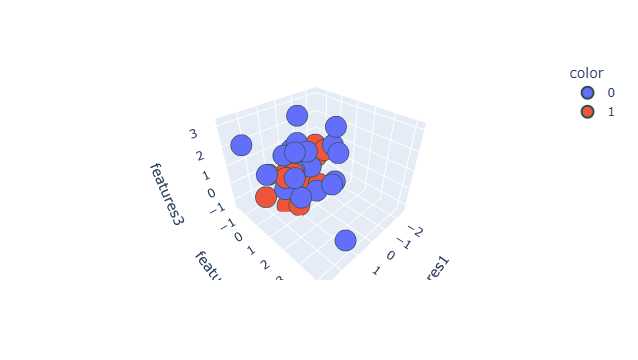

In [11]:
import plotly.express as px
#y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df, x=df['features1'], y=df['features2'], z=df['features3'],
              color=df['target'].astype('str'))
fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))

fig.show()

In [12]:
# Step 1 - Apply standard scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])

In [13]:
# Step 2 - Find Covariance Matrix
covariance_matrix = np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
print('Covariance Matrix:\n', covariance_matrix)
     


Covariance Matrix:
 [[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]


In [14]:
# Step 3 - Finding EV and EVs
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)
     

In [15]:
eigen_values
     

array([1.3536065 , 0.94557084, 0.77774573])

In [16]:
eigen_vectors

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442],
       [-0.52848211,  0.72025103,  0.44938304]])

In [18]:
%pylab inline

from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch


class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        FancyArrowPatch.__init__(self, (0,0), (0,0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def draw(self, renderer):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, renderer.M)
        self.set_positions((xs[0],ys[0]),(xs[1],ys[1]))
        FancyArrowPatch.draw(self, renderer)

fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')

ax.plot(df['features1'], df['features2'], df['features3'], 'o', markersize=8, color='blue', alpha=0.2)
ax.plot([df['features1'].mean()], [df['features2'].mean()], [df['features3'].mean()], 'o', markersize=10, color='red', alpha=0.5)
for v in eigen_vectors.T:
    a = Arrow3D([df['features1'].mean(), v[0]], [df['features2'].mean(), v[1]], [df['features3'].mean(), v[2]], mutation_scale=20, lw=3, arrowstyle="-|>", color="r")
    ax.add_artist(a)
ax.set_xlabel('x_values')
ax.set_ylabel('y_values')
ax.set_zlabel('z_values')

plt.title('Eigenvectors')

plt.show()

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


AttributeError: 'Arrow3D' object has no attribute 'do_3d_projection'

<Figure size 700x700 with 1 Axes>

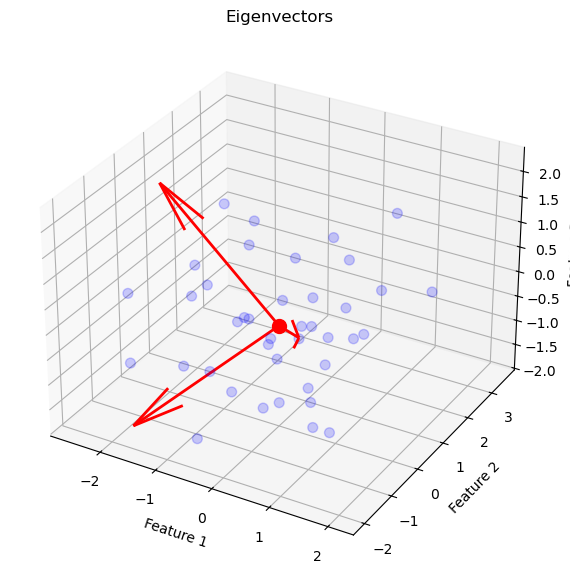

In [19]:
import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')

# scatter plot
ax.scatter(
    df['features1'],
    df['features2'],
    df['features3'],
    color='blue',
    alpha=0.2,
    s=50
)

# mean point
mean_x = df['features1'].mean()
mean_y = df['features2'].mean()
mean_z = df['features3'].mean()

ax.scatter(
    mean_x,
    mean_y,
    mean_z,
    color='red',
    s=100
)

# eigenvectors
for v in eigen_vectors.T:

    ax.quiver(
        mean_x,
        mean_y,
        mean_z,
        v[0],
        v[1],
        v[2],
        color='red',
        linewidth=2,
        length=3
    )

ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Feature 3')

plt.title('Eigenvectors')
plt.show()

In [20]:
import numpy as np
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch

class Arrow3D(FancyArrowPatch):

    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0, 0), (0, 0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def do_3d_projection(self):
        xs3d, ys3d, zs3d = self._verts3d
        return np.min(zs3d)

    def draw(self, renderer):
        xs3d, ys3d, zs3d = self._verts3d

        xs, ys, zs = proj3d.proj_transform(
            xs3d,
            ys3d,
            zs3d,
            self.axes.get_proj()
        )

        self.set_positions(
            (xs[0], ys[0]),
            (xs[1], ys[1])
        )

        super().draw(renderer)

In [22]:
transformed_df = np.dot(df.iloc[:,0:3],pc.T)
# 40,3 - 3,2
new_df = pd.DataFrame(transformed_df,columns=['PC1','PC2'])
new_df['target'] = df['target'].values
new_df.head()

NameError: name 'pc' is not defined

In [ ]:
new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['PC1'],
                 y=new_df['PC2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()